(example_generate_multisite_data_example)=

# Multisite data generation examples.

In [1]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import make_multisite_classification
from uniharmony._verbose import verbosity


sns.set_theme(style="whitegrid")
verbosity("warning")

## We will start with the function as default

X has 1000 examples and 10 features


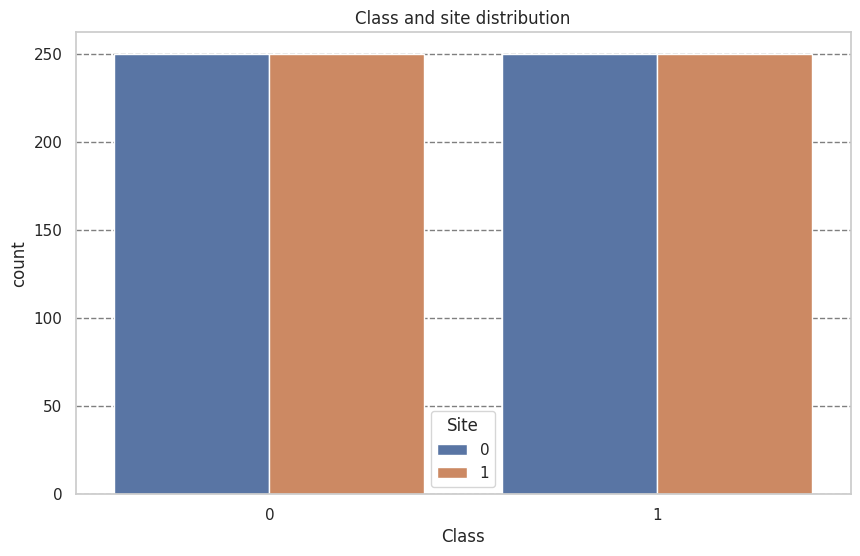

In [2]:
X, y, sites = make_multisite_classification()
df = pd.DataFrame({"Class": y, "Site": sites})
print(f"X has {X.shape[0]} examples and {X.shape[1]} features")

plt.figure(figsize=[10, 6])
plt.title("Class and site distribution")
sns.countplot(df, x="Class", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

Let's increase the number of sites. Note that the total number of samples is the same, but the distribution changed.

For n_sites 2, X has 1000 examples and 10 features
For n_sites 4, X has 1000 examples and 10 features
For n_sites 10, X has 1000 examples and 10 features


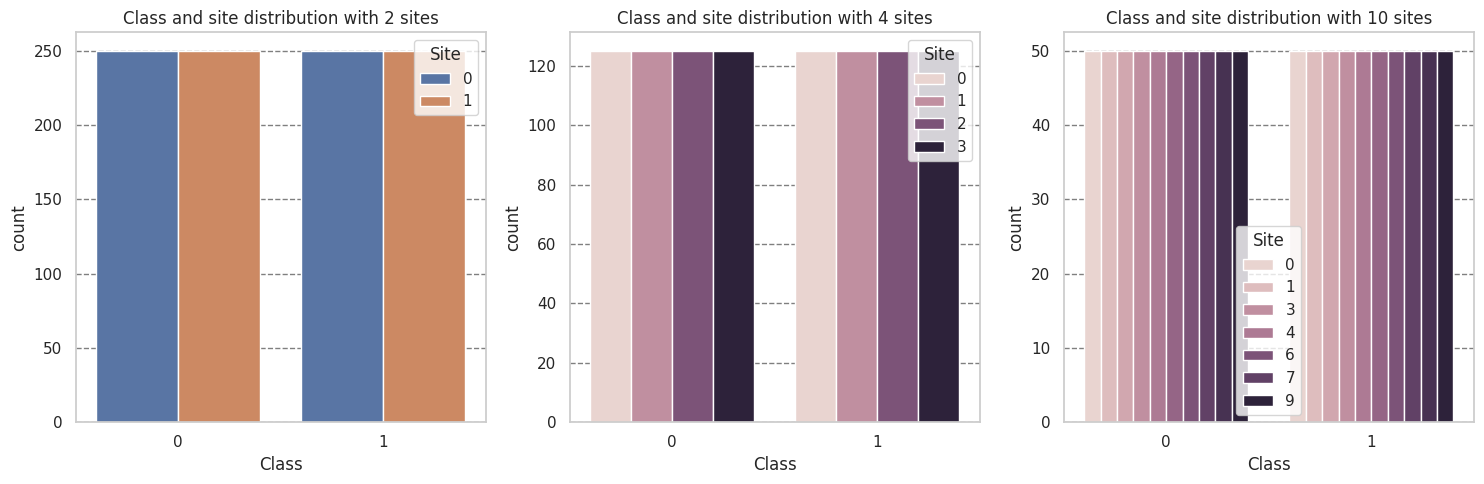

In [3]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, n_sites in enumerate([2, 4, 10]):
    X, y, sites = make_multisite_classification(n_sites=n_sites)
    print(f"For n_sites {n_sites}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    plt.title("Class and site distribution")

    axes[idx].set_title(f"Class and site distribution with {n_sites} sites")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

For n_classes 2, X has 1000 examples and 10 features
For n_classes 4, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features


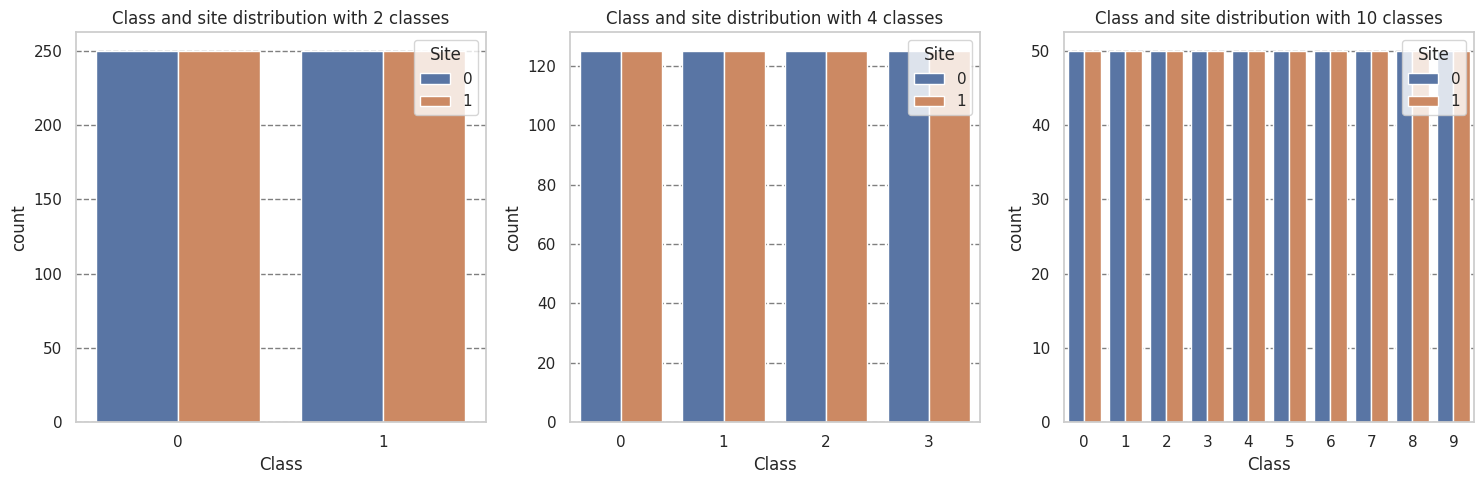

In [4]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, n_classes in enumerate([2, 4, 10]):
    X, y, sites = make_multisite_classification(n_classes=n_classes)
    print(f"For n_classes {n_classes}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Class and site distribution with {n_classes} classes")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

## Changing the class balance:
As default, the created problem is balanced accross sites, so all classes has the same number of examples in each site. 
We can control that using the `balance_per_site` of the function. 

For n_classes 10, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features
For n_classes 10, X has 1000 examples and 10 features


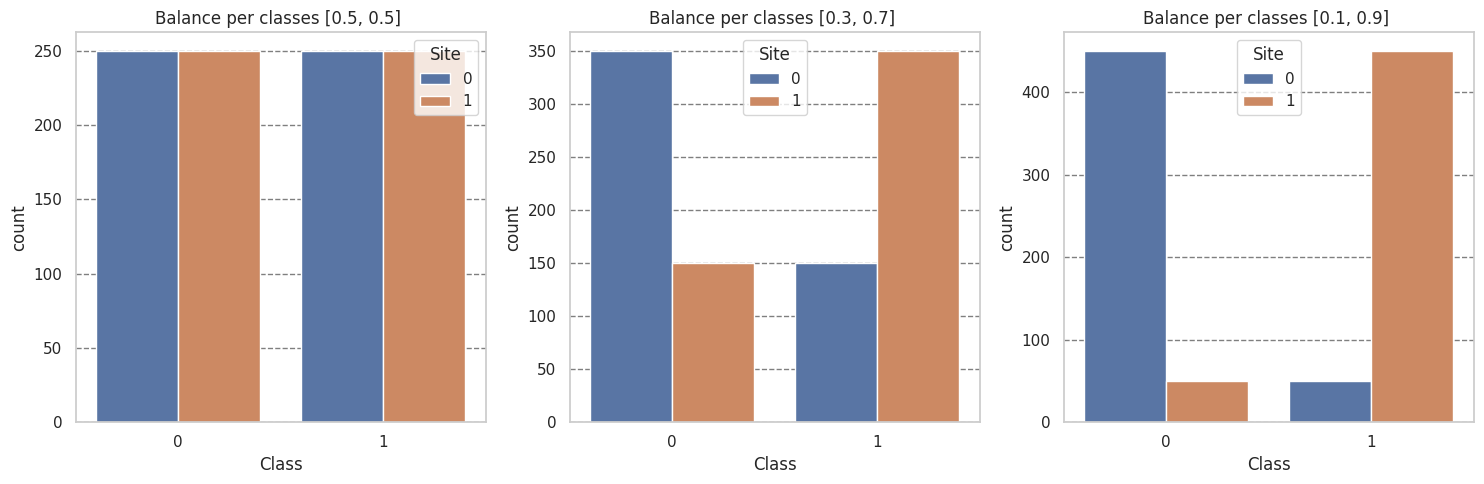

In [5]:
# In a binary classification problem, you need to set which
# proportion of class 1 is present in that site.
# Thus, the number of elements in the list must match the number of sites.
fig, axes = plt.subplots(1, 3, figsize=[15, 5])
balance_per_site_list = [[0.5, 0.5], [0.3, 0.7], [0.1, 0.9]]
for idx, balance_per_site in enumerate(balance_per_site_list):
    X, y, sites = make_multisite_classification(balance_per_site=balance_per_site)
    print(f"For n_classes {n_classes}, X has {X.shape[0]} examples and {X.shape[1]} features")

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )
    sns.countplot(df_plot, x="Class", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Balance per classes {balance_per_site} ")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

Now that we changed the balance, we have different occurence in different sites. Note that the total number of classes is still balanced, is the distribution accross sites that changed.

# Different implemented signal types.
The signal type is used to generate a `base` problem, using sklearn `make` functions. From this generated problem, `uniharmony` adds an Effect of Site and noise on top.

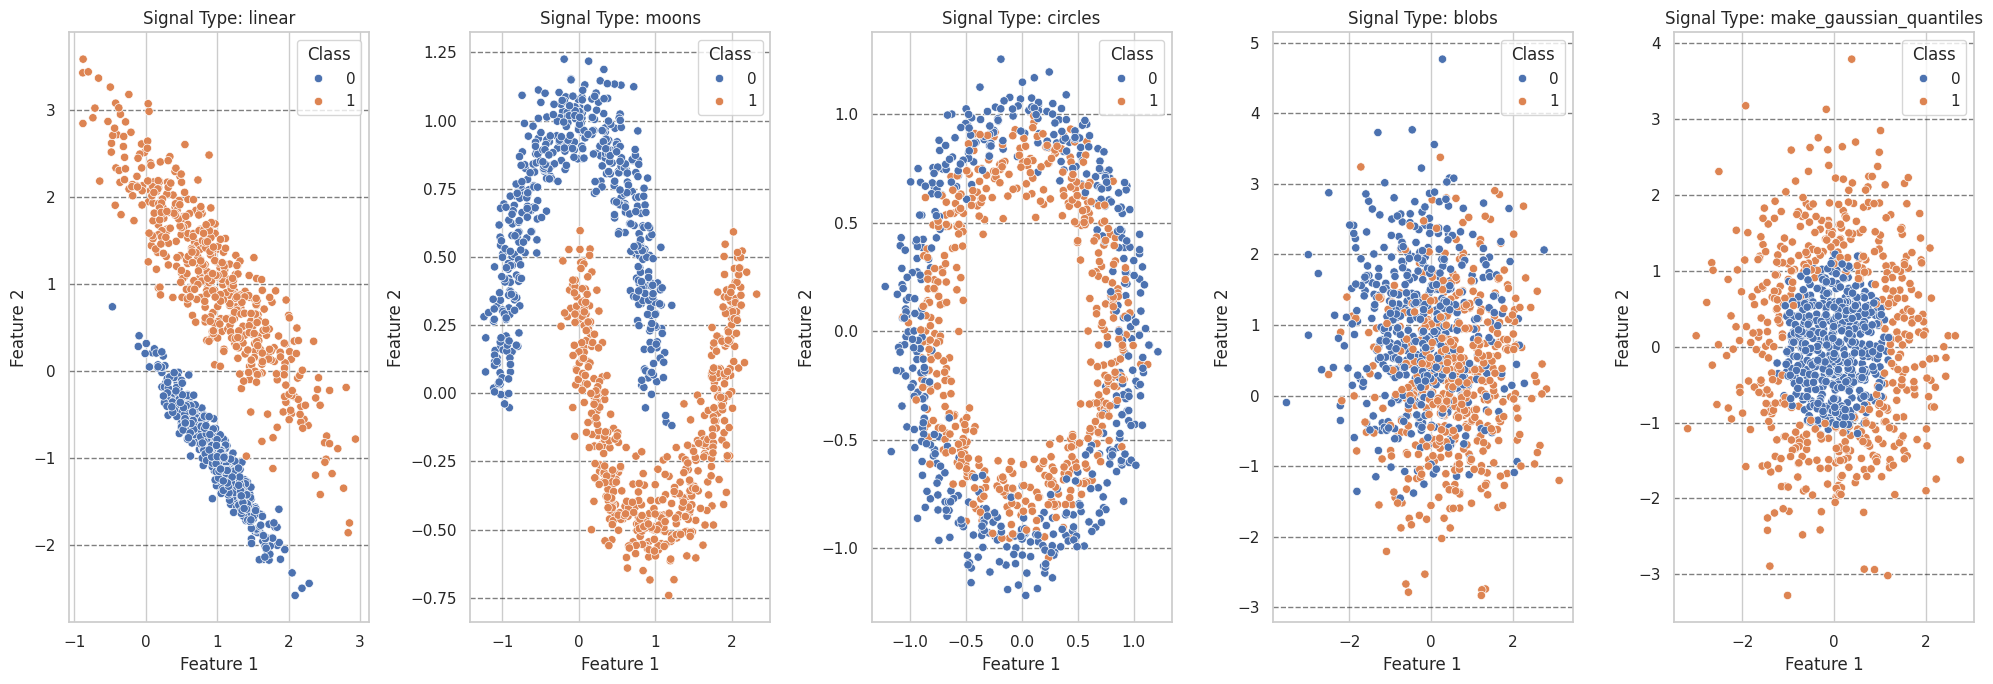

In [6]:
fig, axes = plt.subplots(1, 5, figsize=[20, 7])

for idx, signal_type in enumerate(["linear", "moons", "circles", "blobs", "make_gaussian_quantiles"]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_type=signal_type,
        noise_strength=0.1,
        site_effect_strength=0,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Signal Type: {signal_type}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

# Let's now see how the signal looks like

2026-04-30 01:36:28 [warning  ] signal_strength is 0. Adding a delta (1e-6) to signal_strength to avoid degenerate data.


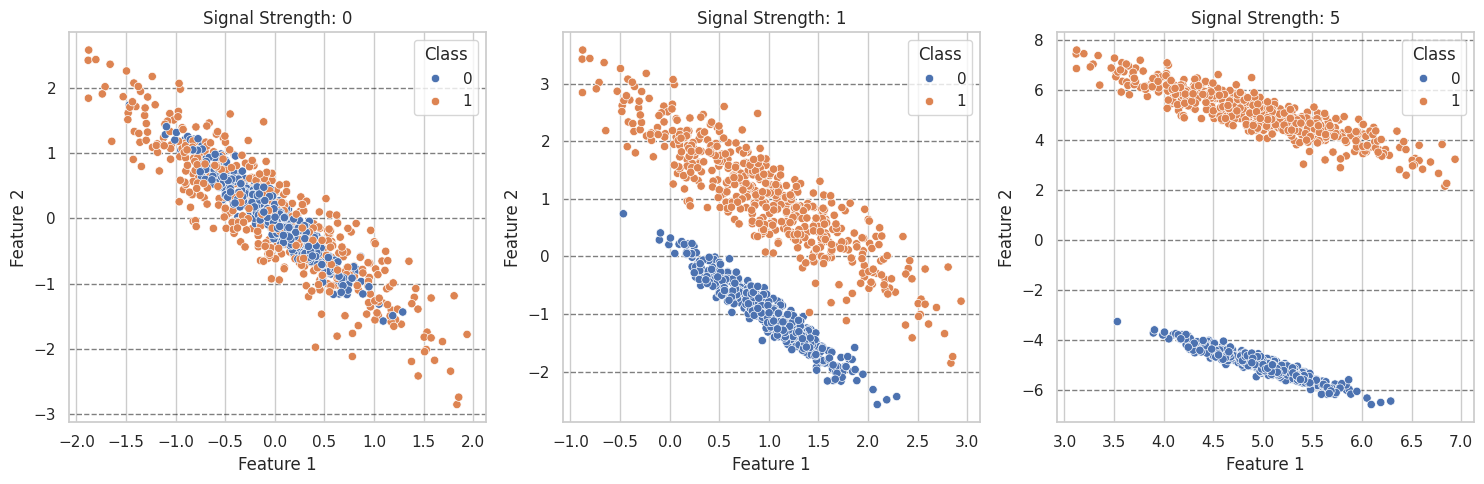

In [7]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, signal_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=signal_st,
        noise_strength=0.1,
        site_effect_strength=0,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Signal Strength: {signal_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

### Effect of Site effect

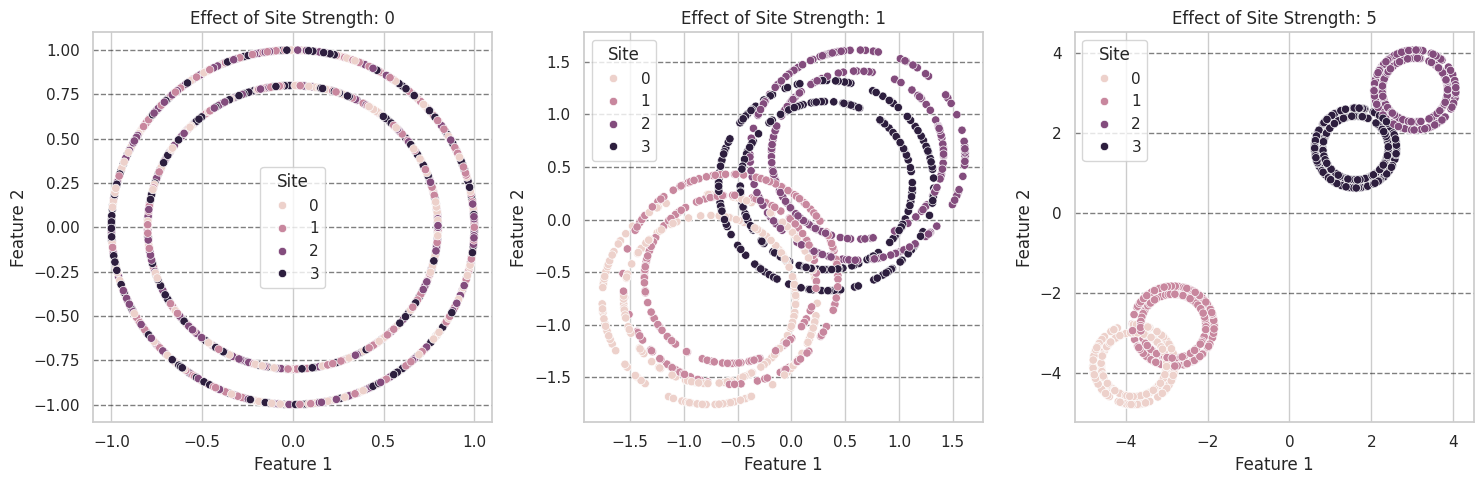

In [8]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, site_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_sites=4,
        n_features=2,
        signal_strength=0.001,
        noise_strength=0,
        site_effect_strength=site_st,
        signal_type="circles",
        site_effect_homogeneous=True,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Effect of Site Strength: {site_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()

## Site effect homogeneous.

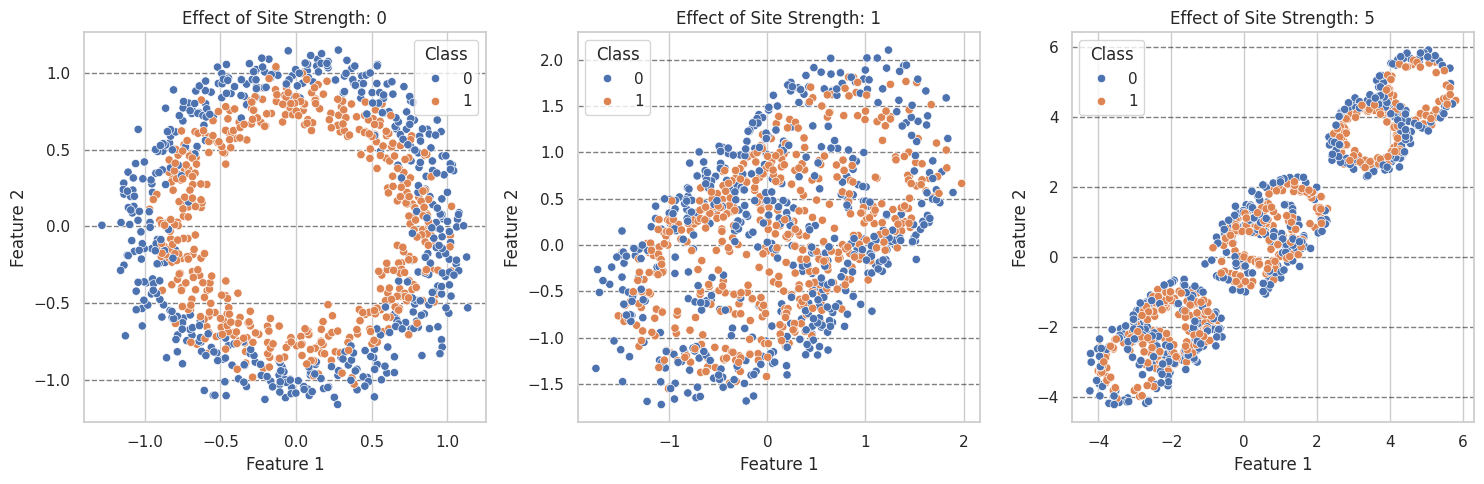

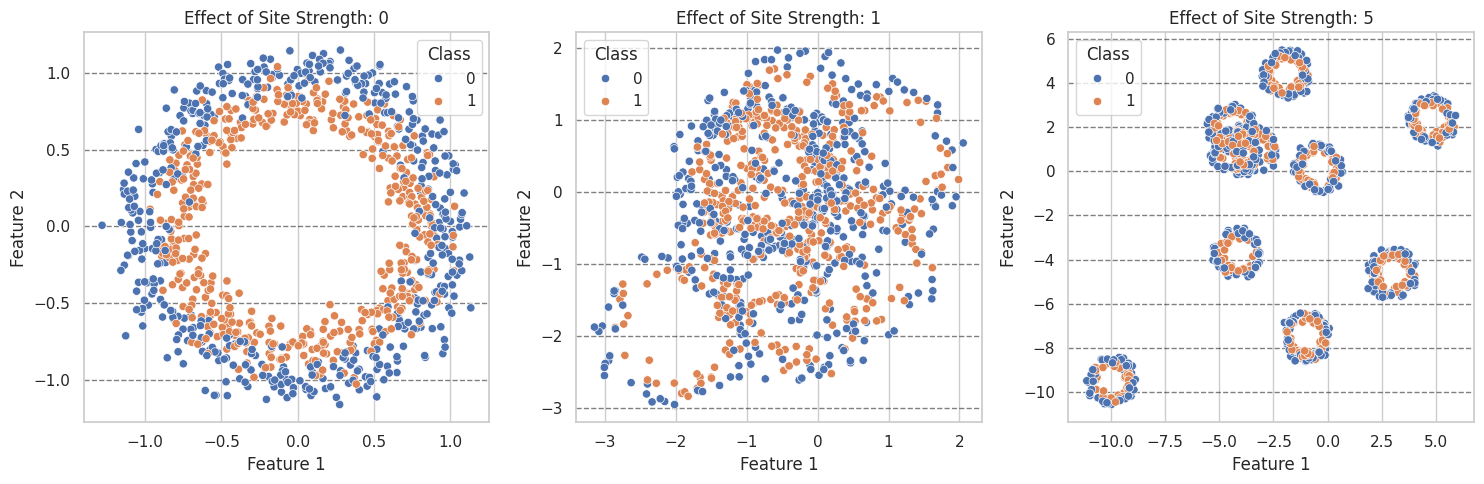

In [9]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, site_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_sites=10,
        n_features=2,
        signal_strength=0.001,
        noise_strength=0,
        site_effect_strength=site_st,
        signal_type="circles",
        noise=0.1,
        site_effect_homogeneous=True,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Effect of Site Strength: {site_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")

plt.tight_layout()
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, site_st in enumerate([0, 1, 5]):
    X, y, sites = make_multisite_classification(
        n_sites=10,
        n_features=2,
        signal_strength=0.001,
        noise_strength=0,
        site_effect_strength=site_st,
        signal_type="circles",
        noise=0.1,
        site_effect_homogeneous=False,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Effect of Site Strength: {site_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

### Noise effect

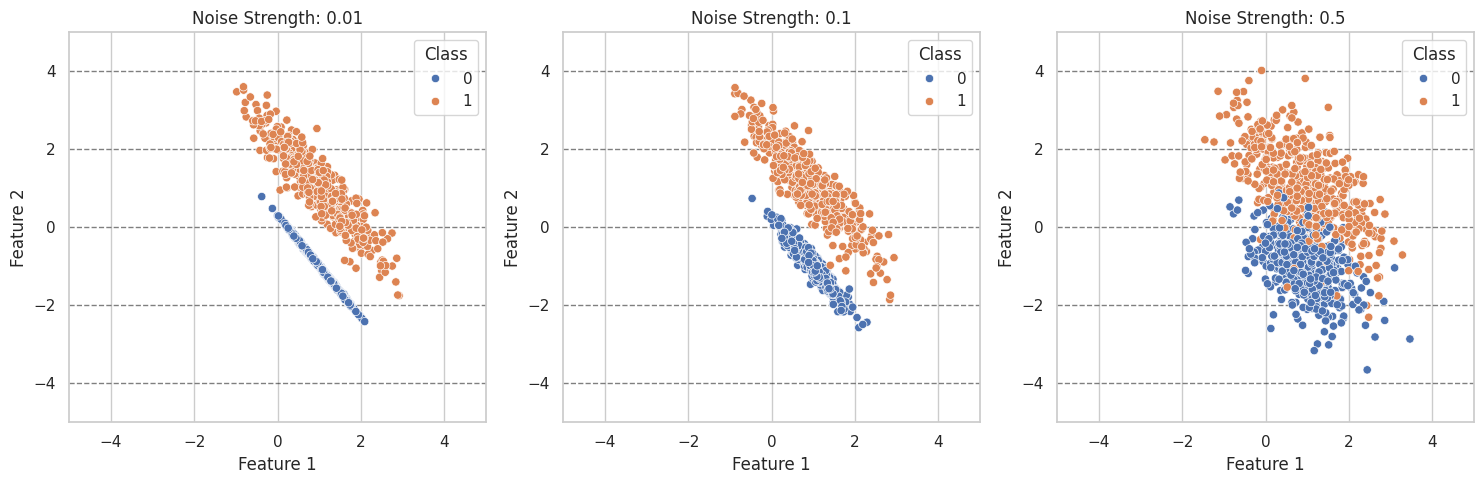

In [10]:
verbosity("warning")

fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, noise_st in enumerate([0.01, 0.1, 0.5]):
    X, y, sites = make_multisite_classification(
        n_features=2,
        signal_strength=1,
        noise_strength=noise_st,
        site_effect_strength=0,
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Class", ax=axes[idx])
    axes[idx].set_title(f"Noise Strength: {noise_st}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")
    axes[idx].set_xlim(-5, 5)
    axes[idx].set_ylim(-5, 5)

plt.tight_layout()

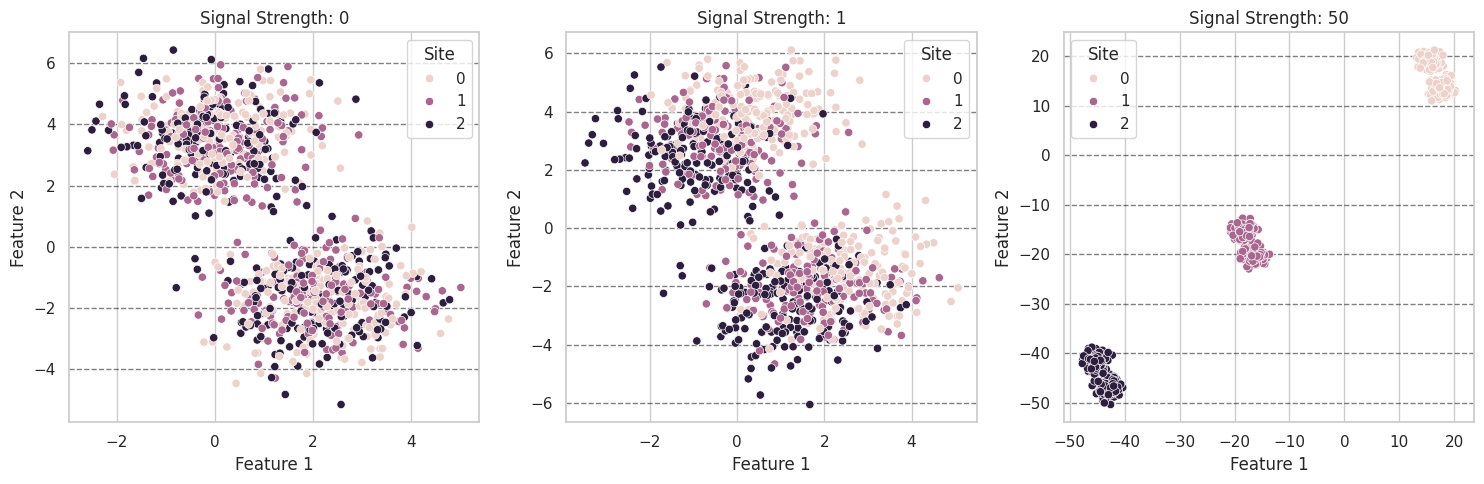

In [15]:
fig, axes = plt.subplots(1, 3, figsize=[15, 5])

for idx, strength in enumerate([0, 1, 50]):
    X, y, sites = make_multisite_classification(
        n_sites=3, n_features=2, signal_strength=4, site_effect_strength=strength, signal_type="blobs", random_state=23
    )

    df_plot = pd.DataFrame(
        {
            "Class": y,
            "Site": sites,
            "Feature 1": X[:, 0],
            "Feature 2": X[:, 1],
        }
    )

    sns.scatterplot(df_plot, x="Feature 1", y="Feature 2", hue="Site", ax=axes[idx])
    axes[idx].set_title(f"Signal Strength: {strength}")
    axes[idx].grid(axis="y", color="black", alpha=0.5, linestyle="--")


plt.tight_layout()